<a href="https://colab.research.google.com/github/UsmanArif169/Machine-Learning-Algorithms-/blob/main/batch_gradient_descent(BGD).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# graient _descent_ step_ by_ step_process

In [1]:
import numpy as np
from sklearn.datasets import make_regression

In [2]:
X,y = make_regression(n_samples = 4 , n_features = 1 , n_informative=1, n_targets = 1, noise =80, random_state =13)

In [3]:
print(X)

[[-0.71239066]
 [ 0.45181234]
 [-0.04450308]
 [ 0.75376638]]


In [4]:
print(y)

[  7.21786552  16.04609925 -27.83756166 144.36688189]


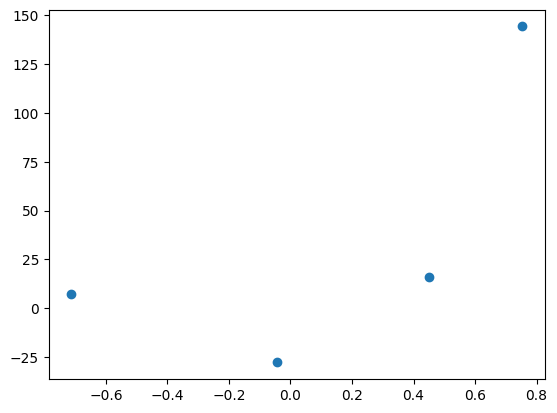

In [5]:
import matplotlib.pyplot as plt
plt.scatter(X,y)

In [8]:
from sklearn.linear_model import LinearRegression

In [9]:
reg = LinearRegression()
reg.fit(X,y)

LinearRegression()

In [10]:
reg.coef_

array([78.35063668])

In [11]:
reg.intercept_

np.float64(26.15963284313262)

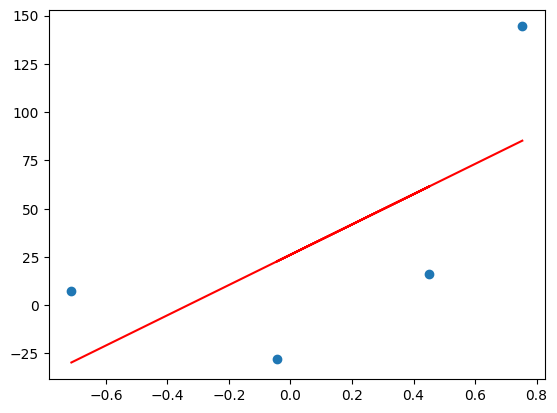

In [12]:
plt.scatter(X,y)
plt.plot(X,reg.predict(X), color = 'red')

In [13]:
# Lets apply Gradient Descent assuming slope is constant m = 78.35
# and let's assume the starting value for intercept b = 0
y_pred = ((78.35*X) + 100).reshape(4)

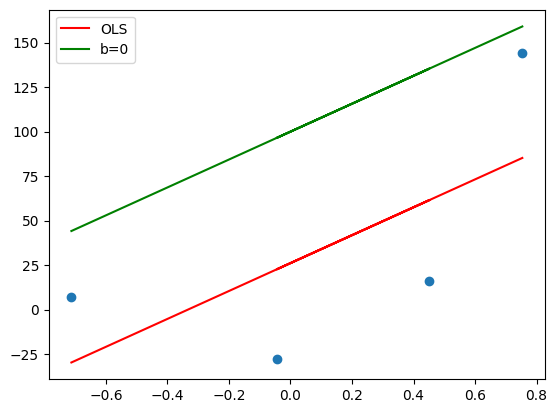

In [14]:
plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red', label = 'OLS')
plt.plot(X,y_pred, color = 'green', label = 'b=0')
plt.legend()
plt.show()

In [15]:
m = 78.35
b = 100

loss_slope= -2 * np.sum(y - m*X.ravel()  - b)
loss_slope

np.float64(590.7223659179078)

In [16]:
# Lets take learning rate = 0.1
lr = 0.1

step_size = loss_slope * lr
step_size


np.float64(59.072236591790784)

In [17]:

# Calculating the new intercept
b = b-step_size
b

np.float64(40.927763408209216)

In [18]:
y_pred1 = ((78.35 * X) + b).reshape(4)

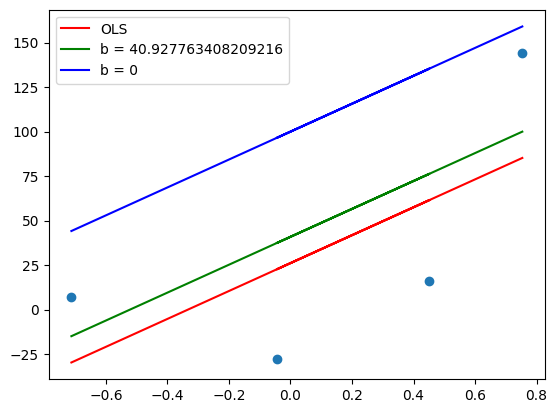

In [19]:
plt.scatter(X,y)
plt.plot(X,reg.predict(X), color = 'red', label = 'OLS')
plt.plot(X,y_pred1, color = 'green', label = 'b = {}'.format(b))
plt.plot(X,y_pred, color = 'blue', label = 'b = 0')
plt.legend()
plt.show()

In [20]:
# Iteration 2
loss_slope = -2 * np.sum(y - m*X.ravel() - b)
loss_slope

np.float64(118.14447318358157)

In [21]:
step_size = loss_slope * lr
step_size

np.float64(11.814447318358157)

In [22]:
b = b - step_size
b

np.float64(29.11331608985106)

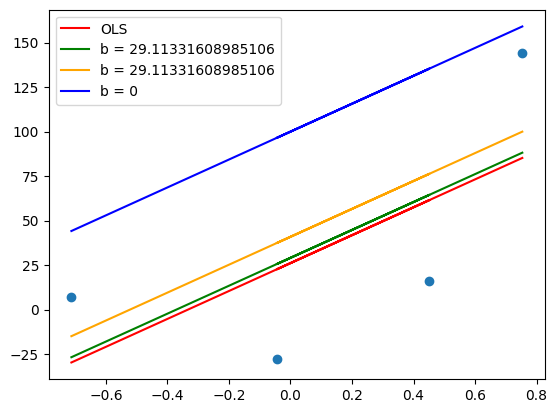

In [23]:
y_pred2 = ((78.35 * X) + b).reshape(4)
plt.scatter(X,y)
plt.plot(X,reg.predict(X), color = 'red', label = 'OLS')
plt.plot(X,y_pred2, color = 'green', label = 'b = {}'.format(b))
plt.plot(X,y_pred1, color = 'orange', label = 'b = {}'.format(b))
plt.plot(X,y_pred, color = 'blue', label = 'b = 0')
plt.legend()
plt.show()

In [24]:
# Iteration 3
loss_slope = -2 * np.sum(y - m*X.ravel() - b)
loss_slope

np.float64(23.62889463671634)

In [25]:
step_size = loss_slope * lr
step_size

np.float64(2.362889463671634)

In [26]:
b = b - step_size
b

np.float64(26.750426626179426)

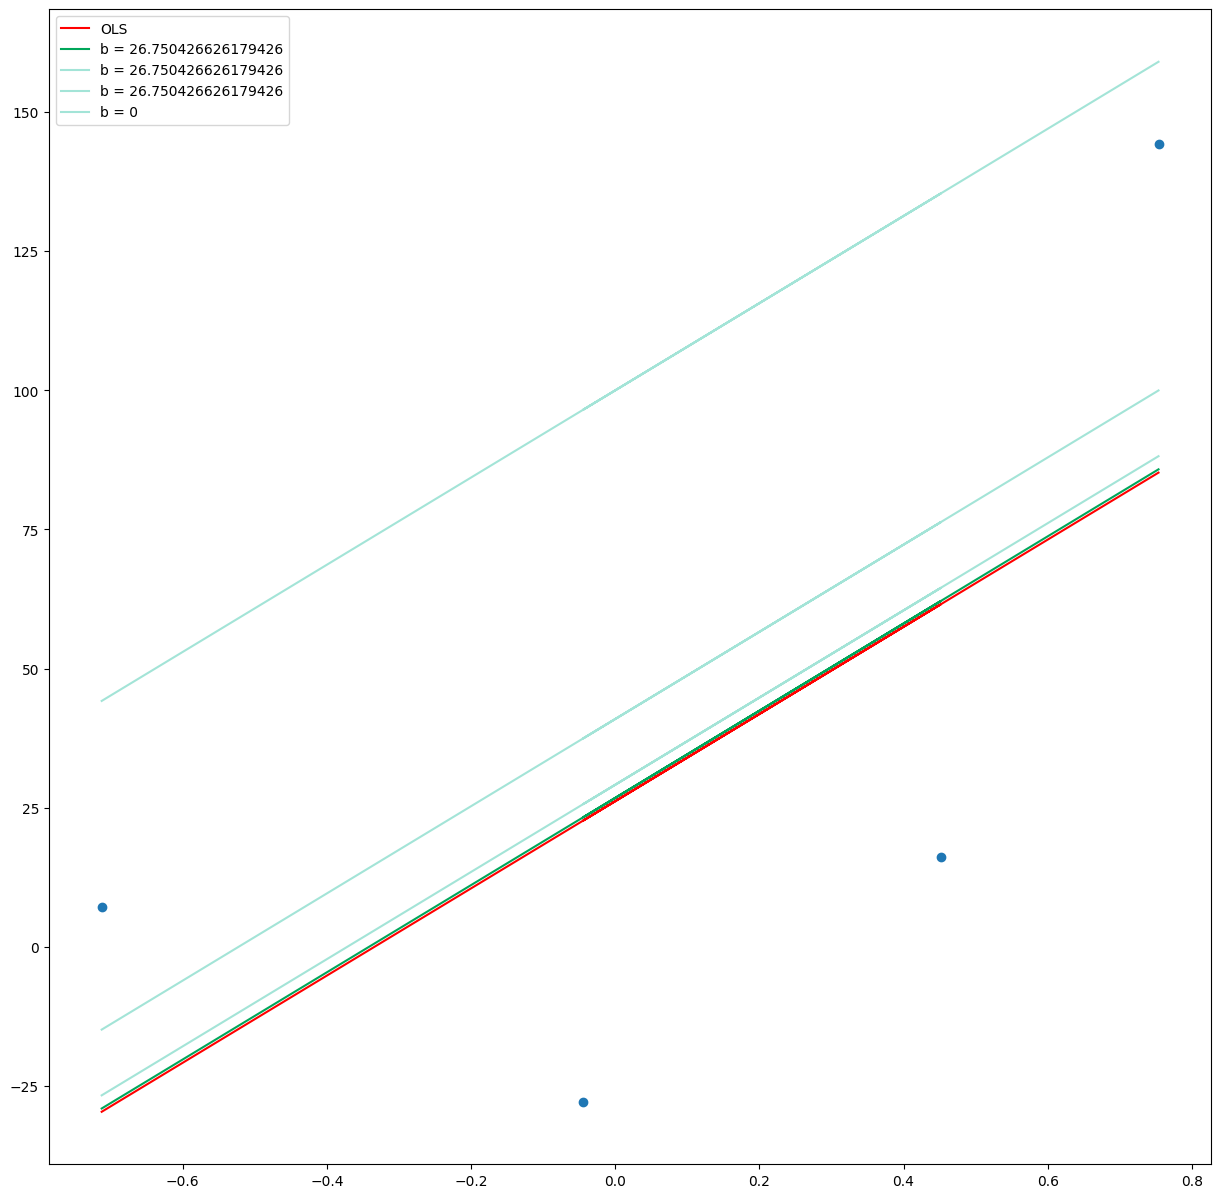

In [27]:
y_pred3 = ((78.35 * X) + b).reshape(4)

plt.figure(figsize=(15,15))
plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label='OLS')
plt.plot(X,y_pred3,color='#00a65a',label='b = {}'.format(b))
plt.plot(X,y_pred2,color='#A3E4D7',label='b = {}'.format(b))
plt.plot(X,y_pred1,color='#A3E4D7',label='b = {}'.format(b))
plt.plot(X,y_pred,color='#A3E4D7',label='b = 0')
plt.legend()
plt.show()


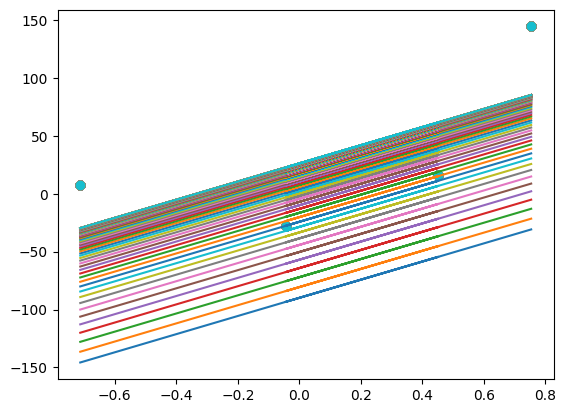

In [28]:
b = -100
m = 78.35
lr = 0.01

epochs = 100

for i  in range(epochs):
  loss_slope = -2 * np.sum(y - m*X.ravel() - b)
  b = b - (lr* loss_slope)
  y_pred = m*X + b
  plt.plot(X,y_pred)
  plt.scatter(X,y)

In [ ]:
#batch-gradient-descent.ipynb

In [29]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import cross_val_score

In [30]:
X,y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1, noise = 20, random_state=13)

In [ ]:
print(X,y)

[[-0.71239066]
 [-0.43714566]
 [-0.45375238]
 [ 0.95283061]
 [ 0.23785784]
 [ 0.86121137]
 [-0.24332625]
 [ 0.18494595]
 [-0.72099967]
 [-0.42989708]
 [ 2.01522083]
 [ 0.39724133]
 [ 0.20780005]
 [-0.23242587]
 [-0.76862702]
 [ 0.45315861]
 [ 0.63988397]
 [ 0.3595323 ]
 [-1.61510796]
 [ 1.74924179]
 [-0.78898902]
 [-0.51196509]
 [-0.92833523]
 [ 2.15038297]
 [-0.2073497 ]
 [-1.63909341]
 [-0.33861825]
 [-0.32212366]
 [-0.48137142]
 [-0.52316421]
 [ 0.72196506]
 [ 0.76591105]
 [ 0.45348104]
 [-1.26160595]
 [-2.18711527]
 [-1.18541881]
 [ 0.21745166]
 [ 1.33031692]
 [-1.08718159]
 [ 0.56226171]
 [-1.51284512]
 [-0.00238903]
 [-0.27813452]
 [ 0.45181234]
 [ 1.19070527]
 [ 0.92234415]
 [ 0.81499544]
 [-0.6209797 ]
 [ 0.9137407 ]
 [ 1.13833305]
 [ 1.47868574]
 [-0.65105648]
 [-0.37591996]
 [-0.77466003]
 [ 0.50113729]
 [ 1.3501879 ]
 [ 0.72916547]
 [-0.08165156]
 [-0.85414295]
 [ 0.46565797]
 [-0.04450308]
 [-0.05753239]
 [ 1.89274222]
 [-1.04537713]
 [ 0.56465429]
 [-1.92415945]
 [-0.76403

In [31]:
print(X.shape)
print(y.shape)

(100, 1)
(100,)


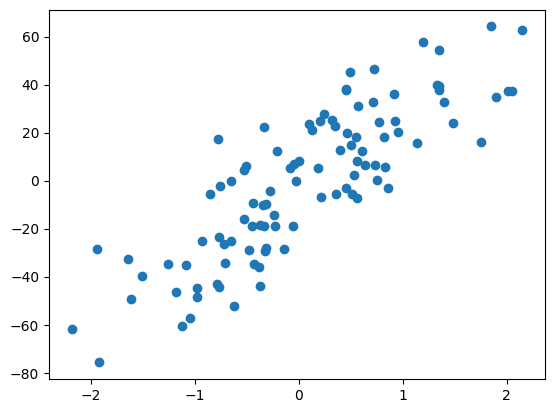

In [32]:
plt.scatter(X,y)

In [33]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y ,test_size=0.2, random_state = 2 )

In [34]:
from sklearn.linear_model import LinearRegression

In [35]:
lr = LinearRegression()

In [36]:
lr.fit(X_train,y_train)

LinearRegression()

In [37]:
print(lr.coef_)


[28.12597332]


In [38]:
print(lr.intercept_)

-2.2710144261783825


In [39]:
y_pred = lr.predict(X_test)

In [40]:
y_pred

array([ 21.09901593,  18.03495551,  18.23747414,  -8.10292651,
        15.72634513,  58.21059953, -15.03324179, -11.33105581,
       -15.81005402,  -8.8082183 , -23.57512364,  14.78144416,
        12.70150681, -23.8893975 , -22.30769518, -16.670531  ,
        24.52827391, -16.98551717,  -3.88916883, -12.01966768])

In [41]:
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.6345158782661012

In [42]:
gd = GDRegressor(0.001, 50)

NameError: name 'GDRegressor' is not defined

In [ ]:
gd

In [ ]:
gd.fit (X_train,y_train)

28.159367347119066 -2.3004574196824854


In [ ]:
gd.predict(X_test)
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.6345158782661012

In [ ]:
# batch-gradient-descent.ipynb using diabetes
from sklearn.datasets import load_diabetes
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

In [ ]:
X,y = load_diabetes(return_X_y = True)

In [ ]:
print(X.shape)
print(y.shape)

(442, 10)
(442,)


In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=2)

In [ ]:
reg = LinearRegression()
reg.fit(X_train,y_train)

LinearRegression()

In [ ]:
print(reg.coef_)


[  -9.15865318 -205.45432163  516.69374454  340.61999905 -895.5520019
  561.22067904  153.89310954  126.73139688  861.12700152   52.42112238]


In [ ]:
print(reg.intercept_)

151.88331005254167


In [ ]:
y_pred = reg.predict(X_test)
r2_score(y_test,y_pred)

0.4399338661568968

In [ ]:
gdr = GDRegressor(epochs = 1000, learning_rate = 0.5)

In [ ]:
gdr.fit(X_train,y_train)

150.46744509611483 [ 1.8185073   0.97792742  2.86819871  2.63829996  1.6514228   1.33631755
 -0.05747848  2.08464246  3.10986813  2.18632166]
150.48030335296843 [ 2.6443041   1.16743591  5.03263979  4.31808847  2.43828072  1.96298164
 -1.45294387  3.56249879  5.2506248   3.50650045]
150.4967712091051 [ 3.46114927  1.3511413   7.18349145  5.98621305  3.21435751  2.57893339
 -2.8372879   5.02556909  7.37622966  4.81446078]
150.5130846311669 [ 4.26912619  1.52910809  9.32087016  7.64277118  3.97976544  3.18429086
 -4.21061415  6.47400032  9.48681324  6.11031462]
150.5292451156878 [ 5.06831704  1.7013948  11.44488367  9.28785819  4.7346121   3.77916355
 -5.5730166   7.90792795 11.58250373  7.39416927]
150.5452540522924 [ 5.8588033   1.86805941 13.55563881 10.92156856  5.47900407  4.3636599
 -6.92458843  9.32748626 13.66342819  8.66613111]
150.56111281805101 [ 6.6406657   2.02915937 15.65324147 12.54399592  6.21304694  4.93788736
 -8.26542196 10.73280826 15.72971257  9.92630553]
150.5768227

In [ ]:
y_pred = gdr.predict(X_test)

In [ ]:
r2_score(y_test,y_pred)

0.4399338661568968